# Assignment 3: Bug Fixing — Fine-tuning & Evaluation
**CSCI 455/555 — Spring 2026 | Prof. Antonio Mastropaolo**

Notebook **2 of 3**. We fine-tune T5-small on the bug-fixing task under two conditions:

| Pipeline | Init | Pre-trained? |
|---|---|---|
| **A** | Load Notebook 1's final checkpoint | Yes (50K Java, 3 epochs span corruption) |
| **B** | Fresh `T5Config(...)`, same tokenizer | No (random weights) |

Hyperparameters are **identical** between A and B — the only variable is whether the model was pre-trained. Evaluation uses CodeBLEU + exact match on the CodeXGLUE `code_refinement` (medium) test set.

## 0.1) Install Dependencies

In [1]:
!pip install -q transformers==4.46.0 tokenizers==0.20.3 sentencepiece==0.2.0
!pip install -q "datasets>=2.21.0" torch tqdm matplotlib
!pip install -q git+https://github.com/k4black/codebleu.git@0.7.1
!pip install -q "tree-sitter==0.23.2" "tree-sitter-java==0.23.5"

from IPython.display import clear_output; #clear_output();
print("Installations Complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.3 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.2/546.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.2/571.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

## 0.2) Imports

In [5]:
import os
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import T5Config, T5Tokenizer, T5ForConditionalGeneration
from datasets import load_dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


## 0.3) Configuration Settings

In [ ]:
# =======================================================================
# Paths
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR        = r"/content/drive/MyDrive/W&M/GenAI/Assignment_3"
TOKENIZER_DIR   = f"{BASE_DIR}/tokenizer"
PRETRAINED_DIR  = f"{BASE_DIR}/pretrained"
FT_DIR_A        = f"{BASE_DIR}/finetuned_A"
FT_DIR_B        = f"{BASE_DIR}/finetuned_B"
RESULTS_DIR     = f"{BASE_DIR}/results"

for d in (FT_DIR_A, FT_DIR_B, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

# =======================================================================
# T5-small architecture (MUST match Notebook 1 — same tokenizer & same config)
D_MODEL, D_FF, D_KV        = 512, 2048, 64
NUM_HEADS                  = 8
NUM_LAYERS, NUM_DEC_LAYERS = 6, 6

# =======================================================================
# Fine-tuning hyperparameters (IDENTICAL for Pipelines A and B)
FT_EPOCHS     = 10
FT_BATCH_SIZE = 16
FT_LR         = 1e-4
MAX_SRC_LEN   = 256
MAX_TGT_LEN   = 256
GRAD_CLIP     = 1.0
RANDOM_SEED   = 42

# =======================================================================
# Evaluation — set to None for full ~6.5K test set; int for a subset
TEST_SUBSET_SIZE = None
GEN_BATCH_SIZE   = 32
NUM_BEAMS        = 4

# =======================================================================
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("✓ Configuration loaded")

✓ Configuration loaded


---
---

# Task 1: Data & Tokenizer

---
---

## 1.1) Load Bug-Fixing Dataset

CodeXGLUE `code_refinement` (medium): ~52K train / 6.5K val / 6.5K test pairs of (buggy, fixed) Java methods.

In [ ]:
ds = load_dataset("google/code_x_glue_cc_code_refinement", "medium", trust_remote_code=True)
print(f"Train : {len(ds['train']):,}")
print(f"Val   : {len(ds['validation']):,}")
print(f"Test  : {len(ds['test']):,}")

ex = ds["train"][0]
print(f"\nBUGGY (first 150 chars): {ex['buggy'][:150]}")
print(f"FIXED (first 150 chars): {ex['fixed'][:150]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/code_x_glue_cc_code_refinement' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/code_x_glue_cc_code_refinement' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restar

README.md: 0.00B [00:00, ?B/s]

medium/train-00000-of-00001.parquet:   0%|          | 0.00/11.9M [00:00<?, ?B/s]

medium/validation-00000-of-00001.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

medium/test-00000-of-00001.parquet:   0%|          | 0.00/1.49M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52364 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6546 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6545 [00:00<?, ? examples/s]

Train : 52,364
Val   : 6,546
Test  : 6,545

BUGGY (first 150 chars): public static TYPE_1 init ( java.lang.String name , java.util.Date date ) { TYPE_1 VAR_1 = new TYPE_1 ( ) ; VAR_1 . METHOD_1 ( name ) ; java.util.Cale
FIXED (first 150 chars): public static TYPE_1 init ( java.lang.String name , java.util.Date date ) { TYPE_1 VAR_1 = new TYPE_1 ( ) ; VAR_1 . METHOD_1 ( name ) ; java.util.Cale


## 1.2) Load Tokenizer from Notebook 1

In [ ]:
tokenizer = T5Tokenizer.from_pretrained(TOKENIZER_DIR, legacy=False)
PAD_ID = tokenizer.pad_token_id
EOS_ID = tokenizer.eos_token_id
print(f"Tokenizer vocab: {len(tokenizer)}")
print(f"PAD={PAD_ID}, EOS={EOS_ID}")

Tokenizer vocab: 16384
PAD=0, EOS=1


## 1.3) `BugFixDataset` and DataLoaders

Input = buggy method (token IDs + EOS), target = fixed method (token IDs + EOS). Labels padded with `-100` so the loss ignores them.

In [ ]:
class BugFixDataset(Dataset):
    def __init__(self, split, tokenizer, max_src=MAX_SRC_LEN, max_tgt=MAX_TGT_LEN):
        self.split = split
        self.tok = tokenizer
        self.max_src = max_src
        self.max_tgt = max_tgt

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        row = self.split[idx]
        src = self.tok.encode(row["buggy"], truncation=True, max_length=self.max_src,
                              add_special_tokens=True)
        tgt = self.tok.encode(row["fixed"], truncation=True, max_length=self.max_tgt,
                              add_special_tokens=True)
        return {"input_ids": torch.tensor(src, dtype=torch.long),
                "labels":    torch.tensor(tgt, dtype=torch.long)}


def collate(batch):
    inp = [b["input_ids"] for b in batch]
    lbl = [b["labels"]    for b in batch]
    mi, ml = max(x.size(0) for x in inp), max(x.size(0) for x in lbl)
    pin = torch.full((len(batch), mi), PAD_ID, dtype=torch.long)
    att = torch.zeros((len(batch), mi),        dtype=torch.long)
    plb = torch.full((len(batch), ml), -100,   dtype=torch.long)
    for i, (x, y) in enumerate(zip(inp, lbl)):
        pin[i, :x.size(0)] = x
        att[i, :x.size(0)] = 1
        plb[i, :y.size(0)] = y
    return {"input_ids": pin, "attention_mask": att, "labels": plb}


train_ds = BugFixDataset(ds["train"],      tokenizer)
val_ds   = BugFixDataset(ds["validation"], tokenizer)
test_ds  = BugFixDataset(ds["test"],       tokenizer)

train_loader = DataLoader(train_ds, batch_size=FT_BATCH_SIZE, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=FT_BATCH_SIZE, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Train batches: 3,273  |  Val batches: 410


---
---

# Task 2: Training Utilities (shared by both pipelines)

---
---

In [ ]:
def evaluate_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            total += out.loss.item()
            n += 1
    return total / n


def finetune(model, train_loader, val_loader, save_dir, tag):
    """Train one pipeline. Same schedule regardless of pre-trained vs scratch."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=FT_LR)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    train_hist, val_hist = [], []

    for epoch in range(FT_EPOCHS):
        model.train()
        running, n = 0.0, 0
        pbar = tqdm(train_loader, desc=f"[{tag}] Epoch {epoch + 1}/{FT_EPOCHS}")
        for batch in pbar:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            if scaler is not None:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    out = model(**batch)
                    loss = out.loss
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(**batch)
                loss = out.loss
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            running += loss.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.3f}")

        train_avg = running / n
        val_avg   = evaluate_loss(model, val_loader)
        train_hist.append(train_avg)
        val_hist.append(val_avg)
        print(f"[{tag}] Epoch {epoch + 1}  train={train_avg:.4f}  val={val_avg:.4f}")

        # Save checkpoint after every epoch
        ckpt_path = f"{save_dir}/epoch_{epoch + 1}"
        model.save_pretrained(ckpt_path)
        tokenizer.save_pretrained(ckpt_path)
        print(f"  ✓ Checkpoint saved → {ckpt_path}")

    # Save final model at the top level of save_dir
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    with open(f"{save_dir}/history.json", "w") as f:
        json.dump({"train_loss": train_hist, "val_loss": val_hist}, f)
    print(f"✓ Saved [{tag}] → {save_dir}")
    return train_hist, val_hist

---
---

# Task 3: Pipeline A — WITH Pre-training

Load the pre-trained checkpoint from Notebook 1 and fine-tune on bug fixing.

---
---

In [ ]:
model_A = T5ForConditionalGeneration.from_pretrained(PRETRAINED_DIR).to(DEVICE)
assert model_A.config.vocab_size == len(tokenizer), "vocab mismatch"
print(f"Loaded pre-trained: {sum(p.numel() for p in model_A.parameters())/1e6:.1f}M params")

train_A, val_A = finetune(model_A, train_loader, val_loader, FT_DIR_A, tag="A")

Loaded pre-trained: 52.4M params


[A] Epoch 1/10: 100%|██████████| 3273/3273 [12:41<00:00,  4.30it/s, loss=0.603]


[A] Epoch 1  train=0.8979  val=0.5354
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_A/epoch_1


[A] Epoch 2/10: 100%|██████████| 3273/3273 [12:36<00:00,  4.32it/s, loss=0.440]


[A] Epoch 2  train=0.5132  val=0.4166
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_A/epoch_2


...

[A] Epoch 8  train=0.3059  val=0.2678
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_A/epoch_8


[A] Epoch 9/10: 100%|██████████| 3273/3273 [12:33<00:00,  4.34it/s, loss=0.266]


[A] Epoch 9  train=0.2732  val=0.2326
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_A/epoch_9


[A] Epoch 10/10: 100%|██████████| 3273/3273 [12:33<00:00,  4.34it/s, loss=0.256]


[A] Epoch 10  train=0.2438  val=0.2040
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_A/epoch_10
✓ Saved [A] → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_A


Optional: resume fine-tuning from previous epoch

In [ ]:
# RESUME_EPOCH = 3  # whatever the last completed epoch was

# model_A = T5ForConditionalGeneration.from_pretrained(f"{FT_DIR_A}/epoch_{RESUME_EPOCH}").to(DEVICE)
# print(f"Resumed from epoch {RESUME_EPOCH}")

# # Temporarily reduce FT_EPOCHS to only run remaining epochs
# original_epochs = FT_EPOCHS
# FT_EPOCHS = original_epochs - RESUME_EPOCH

# train_A, val_A = finetune(model_A, train_loader, val_loader, FT_DIR_A, tag="A")

# FT_EPOCHS = original_epochs  # restore in case you need it later

---
---

# Task 4: Pipeline B — WITHOUT Pre-training

Fresh T5-small, identical config and tokenizer. Random weights — model has never seen the pre-training corpus.

---
---

In [ ]:
t5_config_B = T5Config(
    decoder_start_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    bos_token_id=tokenizer.pad_token_id,
    pad_token_id=tokenizer.pad_token_id,
    d_model=D_MODEL, d_ff=D_FF, d_kv=D_KV,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, num_decoder_layers=NUM_DEC_LAYERS,
    vocab_size=len(tokenizer),
    feed_forward_proj="relu",
)
model_B = T5ForConditionalGeneration(config=t5_config_B)
model_B.resize_token_embeddings(len(tokenizer))
model_B = model_B.to(DEVICE)

print(f"Fresh model:       {sum(p.numel() for p in model_B.parameters())/1e6:.1f}M params")
print("First 5 embedding weights (should be random-init, differ from Pipeline A):")
print(model_B.shared.weight.data[0][:5])

train_B, val_B = finetune(model_B, train_loader, val_loader, FT_DIR_B, tag="B")

Fresh model:       52.4M params
First 5 embedding weights (should be random-init, differ from Pipeline A):
tensor([ 0.0390, -0.2937, -0.6984, -0.2678,  0.4954], device='cuda:0')


[B] Epoch 1/10: 100%|██████████| 3273/3273 [12:30<00:00,  4.36it/s, loss=0.467]


[B] Epoch 1  train=0.8934  val=0.4778
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_B/epoch_1


[B] Epoch 2/10: 100%|██████████| 3273/3273 [12:28<00:00,  4.37it/s, loss=0.401]


[B] Epoch 2  train=0.4659  val=0.3829
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_B/epoch_2


...

[B] Epoch 8  train=0.1167  val=0.0921
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_B/epoch_8


[B] Epoch 9/10: 100%|██████████| 3273/3273 [12:24<00:00,  4.40it/s, loss=0.100]


[B] Epoch 9  train=0.1013  val=0.0872
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_B/epoch_9


[B] Epoch 10/10: 100%|██████████| 3273/3273 [12:24<00:00,  4.39it/s, loss=0.114]


[B] Epoch 10  train=0.0931  val=0.0842
  ✓ Checkpoint saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_B/epoch_10
✓ Saved [B] → /content/drive/MyDrive/W&M/GenAI/Assignment_3/finetuned_B


## Loss Curves — A vs B

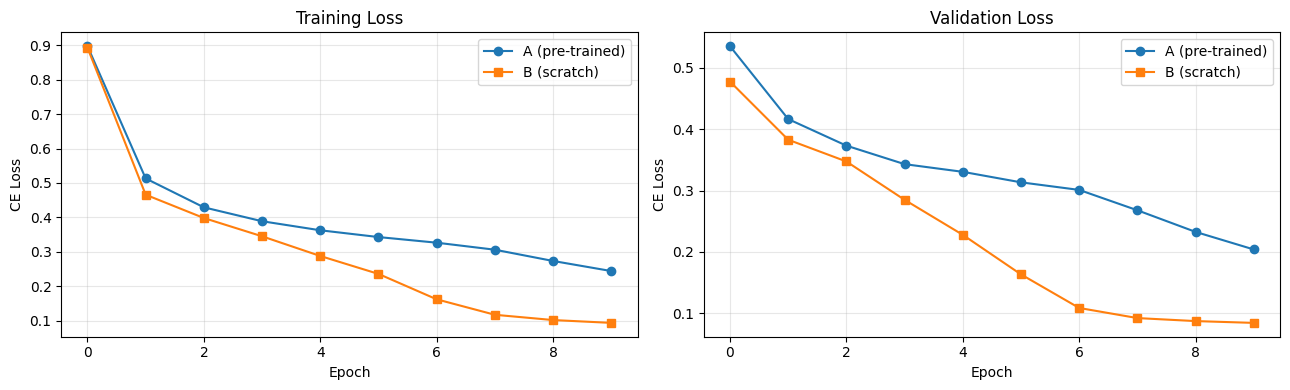

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(train_A, 'o-', label='A (pre-trained)')
ax1.plot(train_B, 's-', label='B (scratch)')
ax1.set(title="Training Loss", xlabel="Epoch", ylabel="CE Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(val_A, 'o-', label='A (pre-trained)')
ax2.plot(val_B, 's-', label='B (scratch)')
ax2.set(title="Validation Loss", xlabel="Epoch", ylabel="CE Loss")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/finetune_loss.png", dpi=150)
plt.show()

---
---

# Task 5: Evaluation — CodeBLEU + Exact Match

Generate fixes for every test-set buggy method with beam search (beams=4). Compute CodeBLEU (n-gram + syntax + dataflow) and exact-match accuracy vs. the reference fix.

---
---

In [ ]:
def generate_predictions(model, hf_split, batch_size=GEN_BATCH_SIZE, max_new=MAX_TGT_LEN,
                         num_beams=NUM_BEAMS, subset=None):
    """Generate one prediction per test instance. Returns (refs, hyps)."""
    model.eval()
    data = hf_split if subset is None else hf_split.select(range(min(subset, len(hf_split))))

    refs, hyps = [], []
    for start in tqdm(range(0, len(data), batch_size), desc="Generating"):
        batch = data[start:start + batch_size]
        enc = tokenizer(batch["buggy"], padding=True, truncation=True,
                        max_length=MAX_SRC_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model.generate(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
                max_new_tokens=max_new,
                num_beams=num_beams,
                early_stopping=True,
            )
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        hyps.extend(decoded)
        refs.extend(batch["fixed"])
    return refs, hyps

## 5.1) Run Generation for Pipeline A and Pipeline B

In [ ]:
model_A = T5ForConditionalGeneration.from_pretrained(f"{FT_DIR_A}/finetuned_A").to(DEVICE)
model_B = T5ForConditionalGeneration.from_pretrained(f"{FT_DIR_B}/finetuned_B").to(DEVICE)

refs_A, hyps_A = generate_predictions(model_A, ds["test"], subset=TEST_SUBSET_SIZE)
refs_B, hyps_B = generate_predictions(model_B, ds["test"], subset=TEST_SUBSET_SIZE)

assert refs_A == refs_B, "reference mismatch between pipelines"
refs = refs_A

# Save raw predictions
with open(f"{RESULTS_DIR}/preds_A.json", "w") as f:
    json.dump({"refs": refs, "hyps": hyps_A}, f)
with open(f"{RESULTS_DIR}/preds_B.json", "w") as f:
    json.dump({"refs": refs, "hyps": hyps_B}, f)

print(f"✓ Generated predictions for {len(refs)} test instances")

# Show a few head-to-head examples
for i in range(3):
    print(f"\n{'=' * 60}\nExample {i+1}")
    print(f"REF   : {refs[i][:160]}")
    print(f"HYP A : {hyps_A[i][:160]}")
    print(f"HYP B : {hyps_B[i][:160]}")

Generating: 100%|██████████| 205/205 [29:43<00:00,  8.70s/it]

✓ Generated predictions for 6545 test instances

Example 1
REF   : public java.lang.String METHOD_1 ( ) { if ( ( METHOD_2 ( ) ) && ( METHOD_3 ( VAR_1 . METHOD_4 ( ) ) ) ) { return VAR_1 . METHOD_4 ( ) ; } else if ( METHOD_3 ( V
HYP A : public java.lang.String METHOD_1 ( ) { if ( ( METHOD_2 ( ) ) && ( METHOD_3 ( ) . METHOD_4 ( VAR_1 ) ) ) { return VAR_2 . METHOD_3 ( ) . METHOD_4 ( ) ; } else if
HYP B : public java.lang.String METHOD_1 ( ) { if ( ( METHOD_2 ( ) ) && ( METHOD_3 ( VAR_1 . METHOD_4 ( ) ) ) ) { return VAR_2 . METHOD_4 ( ) ; } else if ( METHOD_3 ( V

Example 2
REF   : private void METHOD_1 ( TYPE_1 index , java.util.Collection < TYPE_2 > VAR_1 ) { TYPE_1 VAR_2 = index . METHOD_2 ( VAR_3 ) ; for ( TYPE_3 < TYPE_2 > VAR_4 : thi
HYP A : private void METHOD_1 ( TYPE_1 index , java.util.Collection < TYPE_2 > VAR_1 ) { TYPE_2 VAR_2 = index . METHOD_2 ( ) ; for ( TYPE_3 VAR_3 : VAR_1 . values ( ) )
HYP B : private void METHOD_1 ( TYPE_1 index , java.util.Collection < TYPE_2 > VAR_1 

## 5.2) CodeBLEU + Exact Match

In [11]:
from codebleu import calc_codebleu

def exact_match(refs, hyps):
    # Whitespace-normalized string comparison
    norm = lambda s: ' '.join(s.split())
    return sum(norm(r) == norm(h) for r, h in zip(refs, hyps)) / len(refs)


def compute_metrics(refs, hyps, tag):
    cb = calc_codebleu(refs, hyps, lang="java",
                       weights=(0.25, 0.25, 0.25, 0.25))
    em = exact_match(refs, hyps)
    return {
        "tag": tag,
        "n": len(refs),
        "codebleu": round(cb["codebleu"] * 100, 2),
        "ngram_match": round(cb["ngram_match_score"] * 100, 2),
        "weighted_ngram": round(cb["weighted_ngram_match_score"] * 100, 2),
        "syntax_match": round(cb["syntax_match_score"] * 100, 2),
        "dataflow_match": round(cb["dataflow_match_score"] * 100, 2),
        "exact_match": round(em * 100, 2),
    }


metrics_A = compute_metrics(refs, hyps_A, "Pipeline A (pre-trained + fine-tuned)")
metrics_B = compute_metrics(refs, hyps_B, "Pipeline B (fine-tuned only)")

with open(f"{RESULTS_DIR}/metrics_A.json", "w") as f: json.dump(metrics_A, f, indent=2)
with open(f"{RESULTS_DIR}/metrics_B.json", "w") as f: json.dump(metrics_B, f, indent=2)

print(json.dumps(metrics_A, indent=2))
print(json.dumps(metrics_B, indent=2))

{
  "tag": "Pipeline A (pre-trained + fine-tuned)",
  "n": 6545,
  "codebleu": 64.51,
  "ngram_match": 67.73,
  "weighted_ngram": 67.99,
  "syntax_match": 61.0,
  "dataflow_match": 61.3,
  "exact_match": 0.08
}
{
  "tag": "Pipeline B (fine-tuned only)",
  "n": 6545,
  "codebleu": 86.82,
  "ngram_match": 90.5,
  "weighted_ngram": 90.51,
  "syntax_match": 82.46,
  "dataflow_match": 83.82,
  "exact_match": 2.32
}


## 5.3) Side-by-Side Results

In [10]:
def row(m):
    return f"  {m['tag']:<42} | {m['codebleu']:>7.2f} | {m['exact_match']:>7.2f}"

print("=" * 70)
print(f"  {'Config':<42} | {'CodeBLEU':>7} | {'EM (%)':>7}")
print("=" * 70)
print(row(metrics_A))
print(row(metrics_B))
print("=" * 70)

# Detailed CodeBLEU breakdown
print("\nCodeBLEU component breakdown:")
print(f"{'':<42} | {'ngram':>6} | {'w.ngram':>7} | {'syntax':>6} | {'dflow':>6}")
for m in (metrics_A, metrics_B):
    print(f"  {m['tag']:<42} | {m['ngram_match']:>6.2f} | {m['weighted_ngram']:>7.2f} | "
          f"{m['syntax_match']:>6.2f} | {m['dataflow_match']:>6.2f}")

  Config                                     | CodeBLEU |  EM (%)
  Pipeline A (pre-trained + fine-tuned)      |   64.51 |    0.08
  Pipeline B (fine-tuned only)               |   86.82 |    2.32

CodeBLEU component breakdown:
                                           |  ngram | w.ngram | syntax |  dflow
  Pipeline A (pre-trained + fine-tuned)      |  67.73 |   67.99 |  61.00 |  61.30
  Pipeline B (fine-tuned only)               |  90.50 |   90.51 |  82.46 |  83.82
